# Single-cell perturbations: EDA

Each row in `de_train` is a cell type–drug combination. Each gene column contains a DE score: signed −log10(p-value), not raw expression or log-fold change.

This notebook explores the available labeled data. It does not train or evaluate the baseline.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display

# Run this notebook from the Singlecell_perturbations folder.
DATA_DIR = Path("open-problems-single-cell-perturbations")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

# Use Matplotlib defaults, including its default color palette.
plt.style.use("default")
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

## 1. Load the data used by the baseline

Only `de_train` and `id_map` are needed here. The much larger raw single-cell and multiome tables can be explored separately later.

In [3]:
de_train = pd.read_parquet(DATA_DIR / "de_train.parquet")
id_map = pd.read_csv(DATA_DIR / "id_map.csv")

metadata_cols = ["cell_type", "sm_name", "sm_lincs_id", "SMILES", "control"]
gene_cols = [col for col in de_train.columns if col not in metadata_cols]
Y = de_train[gene_cols].to_numpy(dtype=float)

print(f"Labeled combinations: {len(de_train):,}")
print(f"Gene targets: {len(gene_cols):,}")
print(f"Test combinations: {len(id_map):,}")
display(de_train[metadata_cols].head())
display(id_map.head())

Labeled combinations: 614
Gene targets: 18,211
Test combinations: 255


,cell_type,sm_name,sm_lincs_id,SMILES,control
0,NK cells,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False
1,T cells CD4+,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False
2,T cells CD8+,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False
3,T regulatory cells,Clotrimazole,LSM-5341,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,False
4,NK cells,Mometasone Furoate,LSM-3349,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C...,False


,id,cell_type,sm_name
0,0,B cells,5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-...
1,1,B cells,ABT-199 (GDC-0199)
2,2,B cells,ABT737
3,3,B cells,AMD-070 (hydrochloride)
4,4,B cells,AT 7867


## 2. Cell type coverage and shared drugs

Counts below are cell type–drug combinations, not individual cells. The official test set focuses on B cells and myeloid cells.

,Labeled,Official test
cell_type,,
B cells,17,128
Myeloid cells,17,127
NK cells,146,0
T cells CD4+,146,0
T cells CD8+,142,0
T regulatory cells,146,0


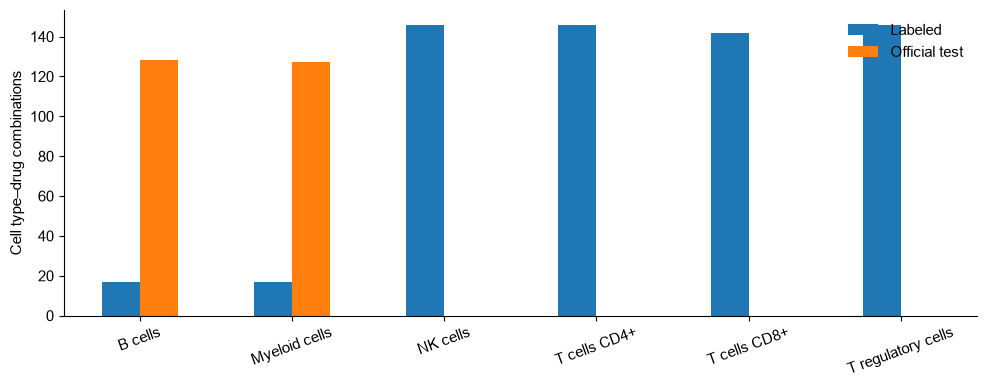

Drugs in labeled data: 146
Drugs in official test: 129
Shared drugs: 129
Test-only drugs: 0


In [4]:
cell_counts = pd.concat([
    de_train.groupby("cell_type").size().rename("Labeled"),
    id_map.groupby("cell_type").size().rename("Official test"),
], axis=1).fillna(0).astype(int)
display(cell_counts)

ax = cell_counts.plot.bar(
    figsize=(10, 4), rot=20
)
ax.set_xlabel("")
ax.set_ylabel("Cell type–drug combinations")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cell_type_coverage.png", dpi=200)
plt.show()

train_drugs = set(de_train["sm_name"])
test_drugs = set(id_map["sm_name"])
print(f"Drugs in labeled data: {len(train_drugs)}")
print(f"Drugs in official test: {len(test_drugs)}")
print(f"Shared drugs: {len(train_drugs & test_drugs)}")
print(f"Test-only drugs: {len(test_drugs - train_drugs)}")

## 3. Gene DE value distribution

Pool all gene scores across all labeled combinations. The first panel includes the full range; the second zooms in on the central 98% (1st–99th percentiles). No random sampling is used.

Values near zero indicate weaker statistical evidence; the sign gives the direction of change. Large absolute scores are not directly the size of the expression change.

Missing / non-finite scores: 0


,DE score
count,1.118155e+07
mean,3.233056e-01
std,2.369097e+00
min,-1.805192e+02
1%,-2.632217e+00
25%,-2.592606e-01
50%,6.143600e-02
75%,4.764335e-01
99%,8.553327e+00
max,1.793242e+02


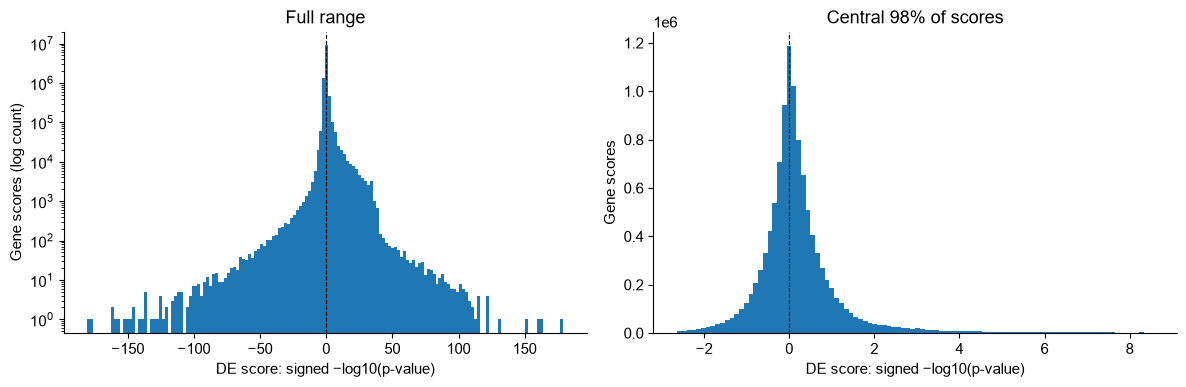

In [5]:
de_values = Y.ravel()
print(f"Missing / non-finite scores: {(~np.isfinite(de_values)).sum():,}")
de_values = de_values[np.isfinite(de_values)]

display(pd.Series(de_values, name="DE score").describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).to_frame())

low, high = np.quantile(de_values, [0.01, 0.99])
central_values = de_values[(de_values >= low) & (de_values <= high)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(de_values, bins=160)
axes[0].set_yscale("log")
axes[0].set_title("Full range")
axes[0].set_ylabel("Gene scores (log count)")
axes[1].hist(central_values, bins=100)
axes[1].set_title("Central 98% of scores")
axes[1].set_ylabel("Gene scores")
for ax in axes:
    ax.set_xlabel("DE score: signed −log10(p-value)")
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "de_distribution.png", dpi=200)
plt.show()

## 4. Response strength by cell type

For each combination, average the absolute DE scores across genes. This summarizes DE score magnitude, not a biological effect size.

,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
B cells,17.0,1.880819,2.506135,0.401370,0.482560,0.587972,1.048860,7.598789
Myeloid cells,17.0,2.192501,2.457819,0.432466,0.534778,1.237534,2.392092,8.423537
NK cells,146.0,0.883664,1.438683,0.377164,0.420403,0.482046,0.578799,9.444240
T cells CD4+,146.0,0.722658,0.934170,0.355079,0.393001,0.448809,0.528912,7.008146
T cells CD8+,142.0,0.572426,0.499676,0.301865,0.341597,0.406089,0.546379,3.485074
T regulatory cells,146.0,0.897326,1.556183,0.293899,0.350333,0.480436,0.839065,16.509588


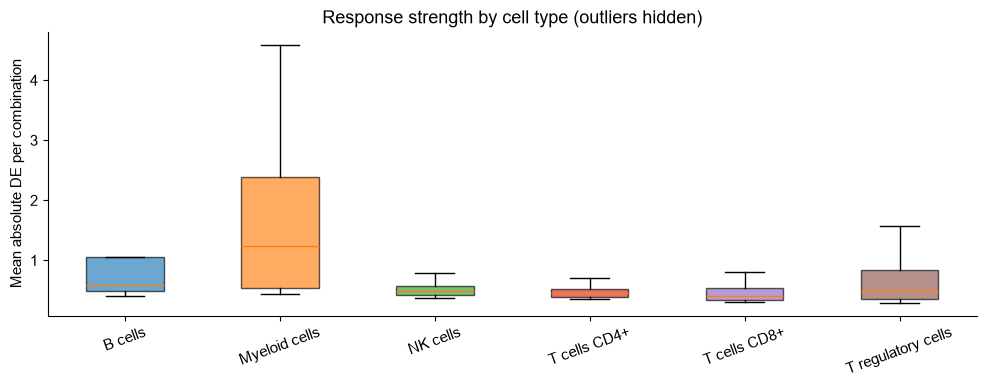

In [6]:
response_strength = pd.DataFrame({
    "cell_type": de_train["cell_type"],
    "mean_absolute_DE": np.abs(Y).mean(axis=1),
})
display(response_strength.groupby("cell_type")["mean_absolute_DE"].describe())

cell_types = sorted(de_train["cell_type"].unique())
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
values_by_type = [
    response_strength.loc[
        response_strength["cell_type"] == cell_type, "mean_absolute_DE"
    ].to_numpy()
    for cell_type in cell_types
]
fig, ax = plt.subplots(figsize=(10, 4))
boxes = ax.boxplot(values_by_type, showfliers=False, patch_artist=True)
ax.set_xticks(range(1, len(cell_types) + 1), cell_types)
for box, color in zip(boxes["boxes"], colors):
    box.set_facecolor(color)
    box.set_alpha(0.65)
ax.tick_params(axis="x", rotation=20)
ax.set_ylabel("Mean absolute DE per combination")
ax.set_title("Response strength by cell type (outliers hidden)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "de_strength_by_cell_type.png", dpi=200)
plt.show()

## 5. PCA of DE profiles: where do cell types lie?

PCA is fitted to the DE targets, not the two input categories. Each point is one cell type–drug combination.

PCA centers each gene but does not standardize its variance, matching the baseline's target preprocessing. Here PCA uses all labeled data for EDA only; during model training, PCA must be fitted only on the training split. Cell type labels are used only to label the plot.

The two-dimensional view keeps only part of the variation. Overlap does not prove that cell types have identical responses; drugs and response strength can also affect the positions.

PC1: 58.31%
PC2: 12.10%
PC1 + PC2: 70.41%
First 160 PCs: 96.80%


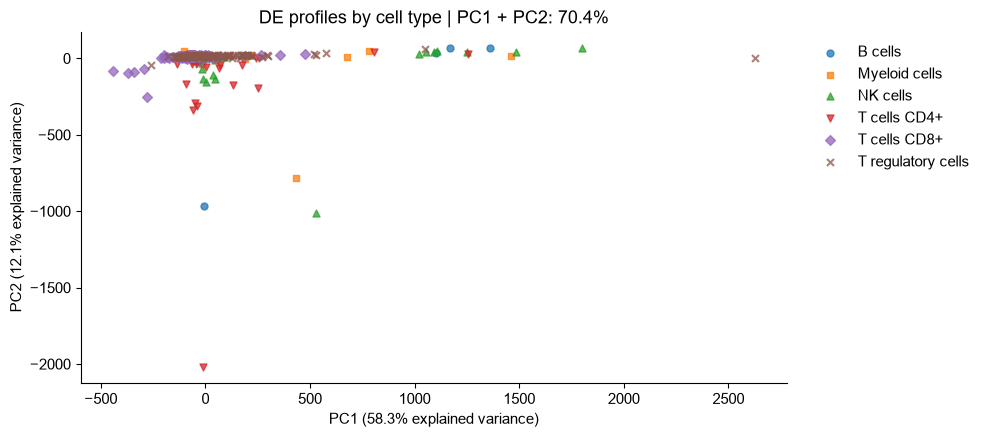

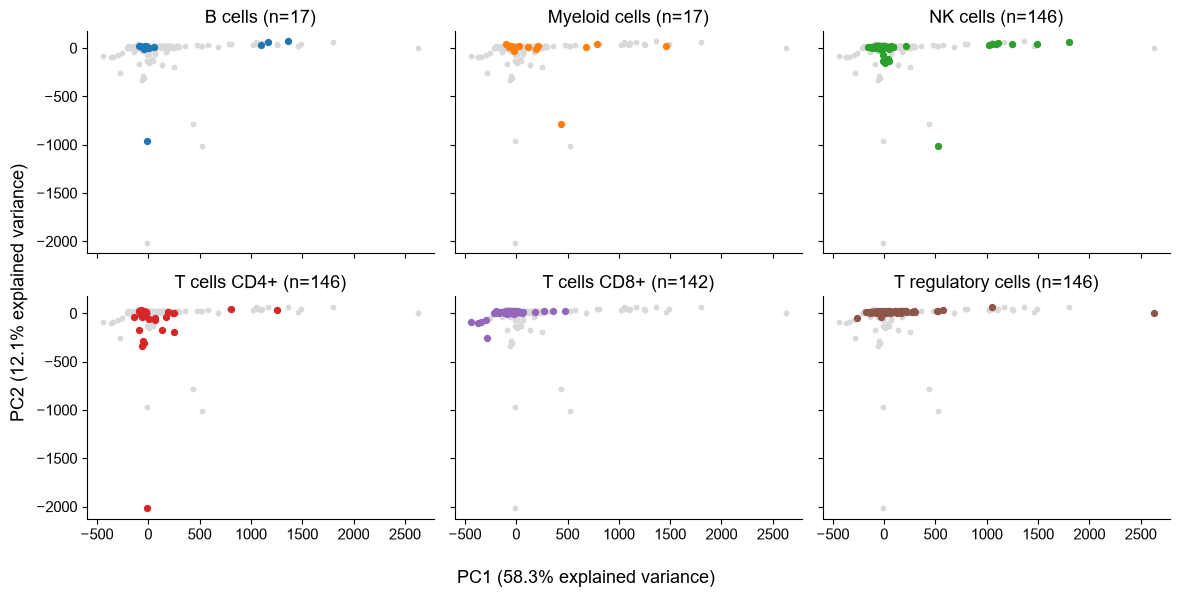

In [7]:
# 50 components let us show both a 2D projection and cumulative variance.
pca = PCA(n_components=160, svd_solver="randomized", random_state=42)
pc_scores = pca.fit_transform(Y)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_df = pd.DataFrame({
    "PC1": pc_scores[:, 0],
    "PC2": pc_scores[:, 1],
    "cell_type": de_train["cell_type"].to_numpy(),
})
print(f"PC1: {explained[0]:.2%}")
print(f"PC2: {explained[1]:.2%}")
print(f"PC1 + PC2: {cumulative[1]:.2%}")
print(f"First 160 PCs: {cumulative[-1]:.2%}")

markers = ["o", "s", "^", "v", "D", "x"]
fig, ax = plt.subplots(figsize=(10, 4.5))
for cell_type, marker, color in zip(cell_types, markers, colors):
    rows = pca_df["cell_type"] == cell_type
    ax.scatter(pca_df.loc[rows, "PC1"], pca_df.loc[rows, "PC2"],
               marker=marker, color=color, s=25, alpha=0.75,
               label=cell_type)
ax.set_xlabel(f"PC1 ({explained[0]:.1%} explained variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} explained variance)")
ax.set_title(f"DE profiles by cell type | PC1 + PC2: {cumulative[1]:.1%}")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "de_pca_by_cell_type.png", dpi=200)
plt.show()

# Same projection and axis limits in all panels; no separate PCA per cell type.
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, cell_type, color in zip(axes.flat, cell_types, colors):
    ax.scatter(pca_df["PC1"], pca_df["PC2"], color="0.85", s=10)
    rows = pca_df["cell_type"] == cell_type
    ax.scatter(pca_df.loc[rows, "PC1"], pca_df.loc[rows, "PC2"],
               color=color, s=18)
    ax.set_title(f"{cell_type} (n={rows.sum()})")
fig.supxlabel(f"PC1 ({explained[0]:.1%} explained variance)")
fig.supylabel(f"PC2 ({explained[1]:.1%} explained variance)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "de_pca_cell_type_panels.png", dpi=200)
plt.show()

## 6. How much variance do the PCs explain?

Individual bars show how much each direction contributes; the curve adds the contributions together. Keeping 50 PCs is a baseline choice, not proof that 50 is optimal. We can compare different numbers using validation MRRMSE.

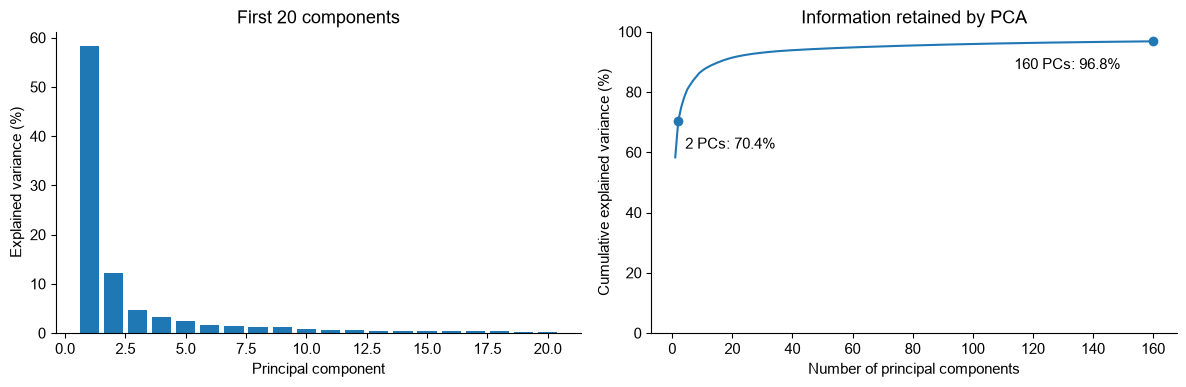

,Number of PCs,Cumulative explained variance (%)
0,1,58.305797
1,2,70.408285
2,10,87.088212
3,20,91.401773
4,160,96.800852


In [8]:
components = np.arange(1, len(explained) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(components[:20], explained[:20] * 100)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("First 20 components")

axes[1].plot(components, cumulative * 100)
axes[1].scatter([2, 160], cumulative[[1, 159]] * 100)
for n in [2, 160]:
    axes[1].annotate(f"{n} PCs: {cumulative[n-1]:.1%}",
                     (n, cumulative[n-1] * 100),
                     xytext=(5 if n == 2 else -100, -20),
                     textcoords="offset points")
axes[1].set_xlabel("Number of principal components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_ylim(0, 100)
axes[1].set_title("Information retained by PCA")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "de_pca_variance.png", dpi=200)
plt.show()

display(pd.DataFrame({
    "Number of PCs": [1, 2, 10, 20, 160],
    "Cumulative explained variance (%)": cumulative[[0, 1, 9, 19, 159]] * 100,
}))

### Interpretation

- Read the cell type panels together with the explained variance; the 2D view does not contain the full DE profile.
- PCA finds directions with large variation. These directions need not correspond to cell type alone.
- This is a descriptive analysis of all labeled data, not a validation result.

Data definition: [Kaggle competition data](https://www.kaggle.com/competitions/open-problems-single-cell-perturbations/data).